In [6]:
# ISMAIL RAJI

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


df = pd.read_csv("Ice_cream selling data.csv")

df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


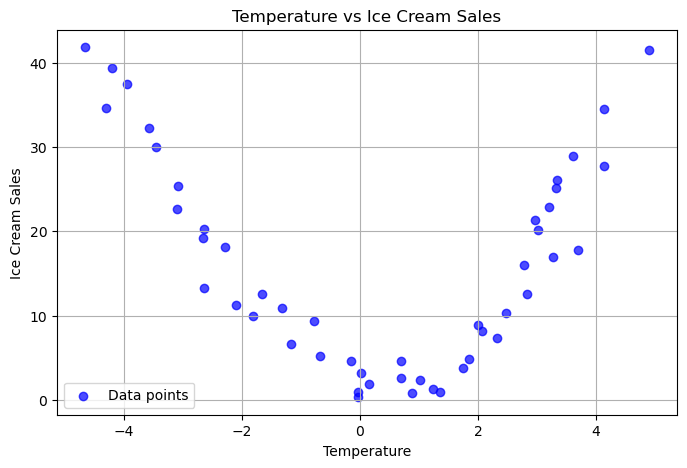

In [12]:
# Visualize the original data
plt.figure(figsize=(8, 5))
plt.scatter(df["Temperature (°C)"], df["Ice Cream Sales (units)"], color="blue", label="Data points",alpha=0.7)
plt.xlabel("Temperature")
plt.ylabel("Ice Cream Sales")
plt.title("Temperature vs Ice Cream Sales")
plt.grid(True)
plt.legend()
plt.show()

In [13]:
x = df[['Temperature (°C)']].values.astype(float)        # Input feature
y = df['Ice Cream Sales (units)'].values.astype(float)   # Target variable

# Create polynomial features (degree=2 or 3 recommended)
degree = 3
poly = PolynomialFeatures(degree=degree)
x_poly = poly.fit_transform(x)

In [14]:
poly_model = LinearRegression()
poly_model.fit(x_poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
print(f"Coefficients: {poly_model.coef_}")
print(f"Intercept: {poly_model.intercept_:.2f}")

Coefficients: [ 0.         -1.48090353  1.8243121   0.05141274]
Intercept: 3.06


In [16]:
x_test = np.array([[2.5]])
x_test_poly = poly.transform(x_test)
predicted_var = poly_model.predict(x_test_poly)
print(f"Predict target: {predicted_var[0]:.0f}")

Predict target: 12


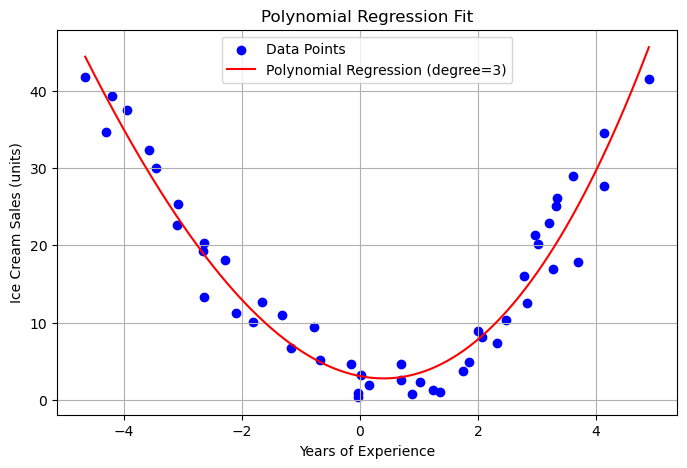

In [17]:
x_range = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
x_range_poly = poly.transform(x_range)
y_range_pred = poly_model.predict(x_range_poly)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label="Data Points")
plt.plot(x_range, y_range_pred, color='red', label=f"Polynomial Regression (degree={degree})")
plt.xlabel("Years of Experience")
plt.ylabel("Ice Cream Sales (units)")
plt.title("Polynomial Regression Fit")
plt.grid(True)
plt.legend()
plt.show()

Epoch 0 | MSE: 400.33 | weights: [ 0.31810616 -0.02711039  3.74153078]
Epoch 100 | MSE: 10.61 | weights: [ 1.77779571 -0.80576964  1.92188051]
Epoch 200 | MSE: 10.11 | weights: [ 2.45583299 -0.81669244  1.86854079]
Epoch 300 | MSE: 10.02 | weights: [ 2.74226636 -0.82130666  1.84600773]
Epoch 400 | MSE: 10.01 | weights: [ 2.86326867 -0.82325591  1.83648876]
Epoch 500 | MSE: 10.00 | weights: [ 2.91438547 -0.82407937  1.83246751]
Epoch 600 | MSE: 10.00 | weights: [ 2.9359795  -0.82442723  1.83076876]
Epoch 700 | MSE: 10.00 | weights: [ 2.94510179 -0.82457418  1.83005113]
Epoch 800 | MSE: 10.00 | weights: [ 2.94895545 -0.82463626  1.82974797]
Epoch 900 | MSE: 10.00 | weights: [ 2.95058341 -0.82466249  1.8296199 ]


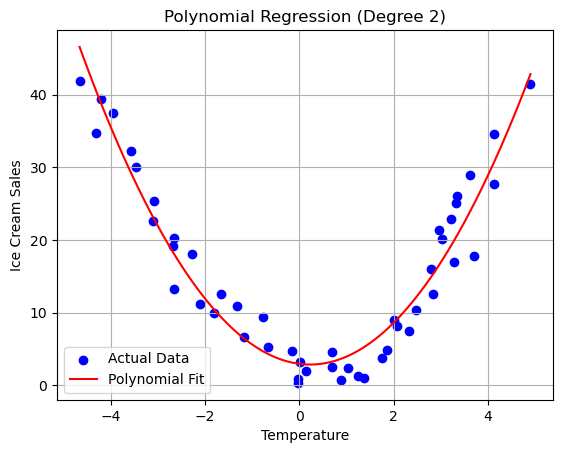


Predicted is cream sales unit for 2.5 Temperature is : 12 units


In [18]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Dataset
df = df # it`s the same 

# Extract Features and Target
X = df["Temperature (°C)"].values.astype(float)
y = df["Ice Cream Sales (units)"].values.astype(float)
n = len(X)

# Create Polynomial Features
degree = 2  # You can change to 3 or more
X_poly = np.vstack([X**i for i in range(1, degree + 1)]).T  # shape: (n, degree)

# Add bias term (column of 1s)
X_poly = np.hstack((np.ones((n, 1)), X_poly))  # shape: (n, degree+1)

# Initialize Parameters
weights = np.zeros(X_poly.shape[1])  # [b, m1, m2, ..., md]
learning_rate = 0.01
epochs = 1000

# Gradient Descent Loop
for epoch in range(epochs):
    y_pred = X_poly.dot(weights)
    error = y - y_pred

    # Compute gradients
    gradients = (-2/n) * X_poly.T.dot(error)

    # Update weights
    weights -= learning_rate * gradients

    # Print every 100 epochs
    if epoch % 100 == 0:
        mse = np.mean(error ** 2)
        print(f"Epoch {epoch} | MSE: {mse:.2f} | weights: {weights}")

# Visualization
plt.scatter(X, y, color='blue', label='Actual Data')

# Generate smooth curve
x_range = np.linspace(X.min(), X.max(), 100)
x_range_poly = np.vstack([x_range**i for i in range(1, degree + 1)]).T
x_range_poly = np.hstack((np.ones((x_range.shape[0], 1)), x_range_poly))
y_curve = x_range_poly.dot(weights)

plt.plot(x_range, y_curve, color='red', label='Polynomial Fit')
plt.xlabel("Temperature")
plt.ylabel("Ice Cream Sales")
plt.title(f"Polynomial Regression (Degree {degree})")
plt.legend()
plt.grid(True)
plt.show()

# Prediction
T = 2.5
input_poly = np.array([T**i for i in range(1, degree + 1)])
input_poly = np.insert(input_poly, 0, 1)  # Add bias term
ic = input_poly.dot(weights)
print(f"\nPredicted is cream sales unit for {T} Temperature is : {ic:.0f} units")

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Charger le fichier

data = pd.read_csv("Ice_cream selling data.csv")

# Nettoyage des noms de colonnes
data.columns = data.columns.str.strip()

print("Colonnes :", data.columns.tolist())

# 2. Définir X et y

X = data['Temperature'].values.reshape(-1, 1)
y = data['Revenue'].values


# 3. Modèle Sklearn

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

# -----------------------------
# 4. MSE
# -----------------------------
mse = mean_squared_error(y, y_pred)

print("\n=== RÉSULTATS ===")
print("Intercept (b0):", model.intercept_)
print("Coefficient (b1):", model.coef_[0])
print("MSE:", mse)


# 5. Graph

# Trier pour une belle ligne
sorted_idx = np.argsort(X.flatten())
X_sorted = X.flatten()[sorted_idx]
y_sorted = y_pred[sorted_idx]

plt.figure(figsize=(10,5))

plt.scatter(X, y, label="Données")
plt.plot(X_sorted, y_sorted, color='red', label="Régression")

plt.xlabel("Temperature")
plt.ylabel("Revenue")
plt.title("Régression Linéaire Simple")
plt.legend()

plt.show()

Colonnes : ['Temperature (°C)', 'Ice Cream Sales (units)']


KeyError: 'Temperature'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Charger les données
data = pd.read_csv("Ice_cream selling data.csv")

data.columns = data.columns.str.strip()

# 2. Variables

T = data['Temperature'].values
y = data['Revenue'].values

# Création variables multiples
X = np.column_stack((T, T**2, T**3))

# 3. Modèle sklearn
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X) 
# 4. MSE
mse = mean_squared_error(y, y_pred)

print("=== RÉGRESSION MULTIPLE ===")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("MSE:", mse)

# 5. GRAPH (projection sur Temperature)
sorted_idx = np.argsort(T)

T_sorted = T[sorted_idx]

X_sorted = np.column_stack((T_sorted, T_sorted**2, T_sorted**3))
y_sorted = model.predict(X_sorted)

plt.figure(figsize=(10,5))

plt.scatter(T, y, label="Données")
plt.plot(T_sorted, y_sorted, color='red', label="Régression multiple")

plt.xlabel("Temperature")
plt.ylabel("Revenue")
plt.title("Régression Multiple (basée sur Temperature)")
plt.legend()

plt.show()